In [178]:
! pip install uncertainties

     ---------------------------------------- 58.3/58.3 kB 1.5 MB/s eta 0:00:00


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from where_linear import LinearDomainFinder
from uncertainties import umath

In [4]:
LDF = LinearDomainFinder()

In [19]:
df = pd.read_csv("../data/millikan_data/t1/t1_p1.csv")

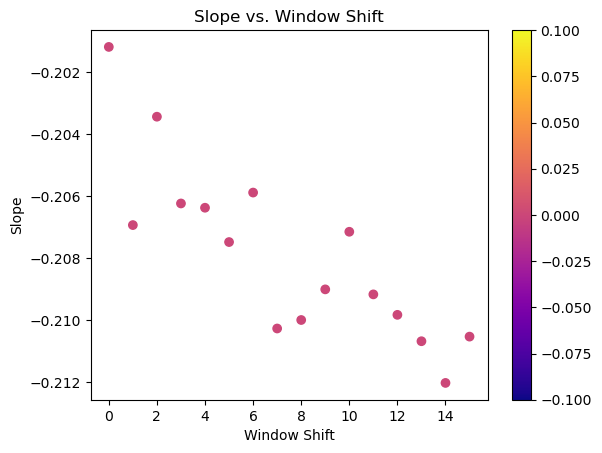

None


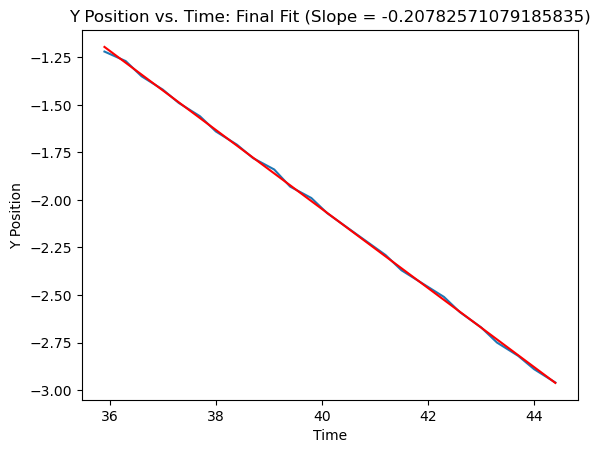

[-0.20782571  6.26532403]
[0.00082861 0.03332709]


In [91]:
LDF.setVerbosity(1)
LDF.setX(df["t"][min:max].to_numpy(),label="Time")
LDF.setY(df["y"][min:max].to_numpy(),label="Y Position")
LDF.slidingWindowFind(WIN_SIZE=10,FDEV_CUT=0.1)
print(LDF.popt)
print(LDF.perr)


In [101]:
vg_ve_data = pd.DataFrame()
vg_ve_data["t1p1_vgs"] = [0.19632657,0.19595886,0]
vg_ve_data["t1p1_ves"] = [0.20786262,0.20684308,0.20782571]
vg_ve_data["t1p1_vg_errs"] = [0.00078119,0.00079532,0]
vg_ve_data["t1p1_ve_errs"] = [0.0010144,0.00081527,0.00082861]

In [114]:
vg = vg_ve_data.t1p1_vgs.mean()
ve = vg_ve_data.t1p1_ves.mean()

In [95]:
df.t

0       0.000
1       0.352
2       0.704
3       1.060
4       1.410
        ...  
127    44.700
128    45.100
129    45.400
130    45.800
131    46.100
Name: t, Length: 132, dtype: float64

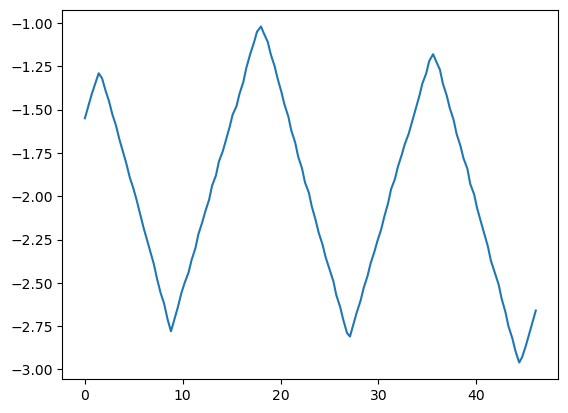

In [96]:
fig,ax = plt.subplots()
min=128
max=170

#ax.plot(df["t"][min:max],df["y"][min:max])
ax.plot(df.t,df.y)


In [105]:
ve1 = 0.09277733117160546
ve2 = 0.09474541217227998
ve3 = 0.09179359262300867
vg1 = 0.2988007625464431
vg2 = 0.30374033136659373
vg3 = 0.3019558036065546


In [106]:
vg = np.mean([vg1,vg2,vg3])
ve = np.mean([ve1,ve2,ve3])
np.std([vg1,vg2,vg3])
#np.std([ve1,ve2,ve3])

0.002042279868359104

In [107]:
vg

0.30149896583986385

In [108]:
ve

0.09310544532229803

In [112]:
def q(ve,vg):
    d = 4.56e-3 # m
    V = 400 # V
    eta = 18.13e-6 #N*s/m^2
    b = 6.17e-6 # m*cmHg
    P = 76 #cmHg
    rho = 0.86e3 #kg/m^3
    g = 9.801 #m/s^2
    a = np.sqrt((9*eta*vg)/(2*g*rho))
    return [a,((6*np.pi*d/V)*np.sqrt((9*eta**3)/(2*rho*g))*(ve+vg)*(np.sqrt(vg))*(1+(b/(a*P)))**(-3/2))]


In [124]:
 q(ve*10**-3,vg*10**-3)[1]/(1.602*(10**-19))

8.33639105674738

In [ ]:
first_calc = [1.7082980774613358e-06, 2.449535502776281e-18] #[a,q]
[1.1250224797549037e-06, 1.33548984729093e-18]